In [ ]:
#pip install seaborn

In [ ]:
#pip install pandasql

!pip install pandasql

In [2]:
import pandas as pd
import pandasql as psql
import numpy as np


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
def graficoBarApiladas(data,variable,y):
    # Crear una tabla de contingencia
    contingency = pd.crosstab(data[variable], data[y])

    # Crear el gráfico de barras apiladas
    contingency.plot(kind='bar', stacked=True, colormap='viridis')

    # Añadir etiquetas y título
    plt.xlabel(variable)
    plt.ylabel('%')
    plt.title('Grafico '+variable+'  '+ y)

    # Mostrar el gráfico
    plt.show()
    
def targetToBinary(r):
    if r['Target']=='yes':
        return 1
    return 0    

In [5]:
marketing = pd.read_csv('data/bank-full.csv',sep=',')

Convertimos el target a binario

In [6]:
marketing['y']=marketing.apply(targetToBinary,axis=1)

In [7]:
consulta ='SELECT * FROM marketing'

rs = psql.sqldf(consulta,locals())

In [8]:
rs.head(2)

,age,job,marital,education,default_,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0


In [9]:
rs.Target.value_counts()

Target
no     39922
yes     5289
Name: count, dtype: int64

### Datos demográficos

a. ¿ Cuál es la edad media de los clientes con estado civil "married"?

In [10]:
consulta = " SELECT avg(age) FROM marketing WHERE marital='married' "

rs = psql.sqldf(consulta,locals())

In [11]:
rs

,avg(age)
0,43.408099


b. ¿ Como se distribuye el estado civil de los clientes de 31 años?

In [12]:
consulta ="select count(*),marital FROM marketing WHERE age = 31 GROUP BY marital" 

rs = psql.sqldf(consulta,locals())

In [13]:
rs

,count(*),marital
0,98,divorced
1,881,married
2,1017,single


### Datos financieros

a. De los clientes que tienen un préstamo Hipotecario, ¿cuántos tienen un préstamo personal?

In [14]:
consulta =" select count(*) as clientesPrestamos from marketing where housing='yes' and loan = 'yes' "

rs = psql.sqldf(consulta,locals())

In [15]:
rs

,clientesPrestamos
0,4367


b. ¿Cuantos de los clientes con profesión "management" tienen un balance anual positivo?

In [16]:
consulta =" select count(*) as balanceAnualPositivo from marketing where job ='management' and balance > 0"

rs = psql.sqldf(consulta,locals())

In [17]:
rs

,balanceAnualPositivo
0,8053


c. ¿Cuántos de los clientes con educación "Tertiary" tienen un crédito en default?

In [18]:
consulta ="select count(*) as clienteTertiaryCreditoDefault from marketing where education='tertiary' and default_ ='yes'"

rs = psql.sqldf(consulta,locals())

In [19]:
rs

,clienteTertiaryCreditoDefault
0,198


### Contactos de campañas

a. ¿Cuanto es el número de contactos medio de la campaña actual de los clientes contactados por última vez en mayo?

In [20]:
consulta ="select avg(campaign) as contactosMedios from marketing where month ='may' "

rs = psql.sqldf(consulta,locals())

In [21]:
rs

,contactosMedios
0,2.447552


b.¿Son los clientes contactados en junio, los que muestran una mayor duración media?

In [22]:
consulta ="select avg(campaign), month from marketing GROUP BY month"
rs = psql.sqldf(consulta,locals())

In [23]:
rs

,avg(campaign),month
0,1.955321,apr
1,3.927325,aug
2,2.196262,dec
3,2.382031,feb
4,1.672131,jan
5,3.524438,jul
6,3.135368,jun
7,2.205451,mar
8,2.447552,may
9,1.918136,nov


### Deposito a Plazo

a.- Independiemtemente del "estado civil" del cliente, la proporción de contratación de depósito a 
plazo no cambia, siempre es la misma. ¿esta afirmación es correcta?


In [32]:
consulta ="  select marital, count(*) AS Clientes, sum(case when target = 'yes' then 1 else 0 end) as targetYes from marketing GROUP BY marital"
rs = psql.sqldf(consulta,locals())   

In [33]:
rs

,marital,Clientes,targetYes
0,divorced,5207,622
1,married,27214,2755
2,single,12790,1912


In [36]:
consulta = """
SELECT 
    A.marital,
    A.n_depositos,
    B.t_depositos, 
    (A.n_depositos * 100.0 / B.t_depositos) as rto_depositos 
FROM 
    (SELECT 
        marital, 
        SUM(CASE WHEN Target = 'yes' THEN 1 ELSE 0 END) as n_depositos 
     FROM marketing 
     GROUP BY marital) A,
    (SELECT 
        SUM(CASE WHEN Target = 'yes' THEN 1 ELSE 0 END) as t_depositos 
     FROM marketing) B
"""

rs = psql.sqldf(consulta, locals())

In [38]:
rs

,marital,n_depositos,t_depositos,rto_depositos
0,divorced,622,5289,11.760257
1,married,2755,5289,52.089242
2,single,1912,5289,36.150501


b.- Observa la tenencia de hipoteca, ¿ crees que es una variable útil para predecir si un cliente puede contratar un Depósito a plazo ?

In [ ]:
# Consulta SQL para analizar la conversión según tenencia de hipoteca
consulta = """
SELECT 
    housing,
    COUNT(*) as Total_Clientes,
    SUM(CASE WHEN Target = 'yes' THEN 1 ELSE 0 END) as Total_Contrataciones,
    AVG(CASE WHEN Target = 'yes' THEN 1.0 ELSE 0.0 END) as Tasa_Conversion
FROM marketing
GROUP BY housing
ORDER BY Tasa_Conversion DESC
"""

# Ejecutamos la consulta
rs = psql.sqldf(consulta, locals())

In [ ]:
rs

,housing,Total_Clientes,Total_Contrataciones,Tasa_Conversion
0,no,20081,3354,0.167024
1,yes,25130,1935,0.077000


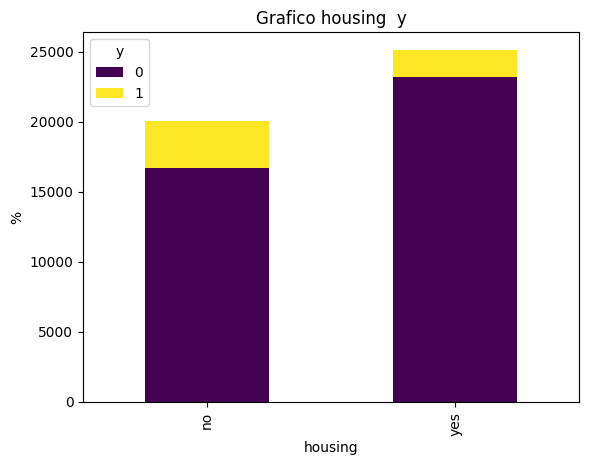

In [43]:
graficoBarApiladas(marketing,'housing','y')

Como vimos que hay mucha diferencia entre tener o no hipoteca, el valor debería ser medio o alto (probablemente superior a 0.02 o incluso 0.1), lo que confirmaría que es una variable importante para tu modelo.

c.¿Podríamos asumir que, a mayor duración de la llamada, hay mayor probabilidad de contratar un 
depósito a plazo (target='yes')?

In [44]:
consulta = """
SELECT 
    CAST(duration/60 AS INT) as duracion_minutos,
    COUNT(*) as total_clientes,
    SUM(CASE WHEN Target = 'yes' THEN 1 ELSE 0 END) as ventas,
    AVG(CASE WHEN Target = 'yes' THEN 1.0 ELSE 0.0 END) as tasa_conversion
FROM marketing
GROUP BY duracion_minutos
ORDER BY duracion_minutos ASC
LIMIT 15
"""
rs = psql.sqldf(consulta, locals())

In [40]:
rs

,duracion_minutos,total_llamadas,ventas,tasa_conversion
0,0,4659,9,0.001932
1,1,9249,195,0.021083
2,2,8629,497,0.057596
3,3,6062,585,0.096503
4,4,4283,536,0.125146
5,5,2923,414,0.141635
6,6,2128,380,0.178571
7,7,1499,302,0.201468
8,8,1122,283,0.252228
9,9,855,251,0.293567


In [49]:
consulta = """
SELECT 
    duration,
    Target as y,
    NTILE(10) OVER (ORDER BY duration) as decil
FROM marketing
"""

rs = psql.sqldf(consulta, locals())

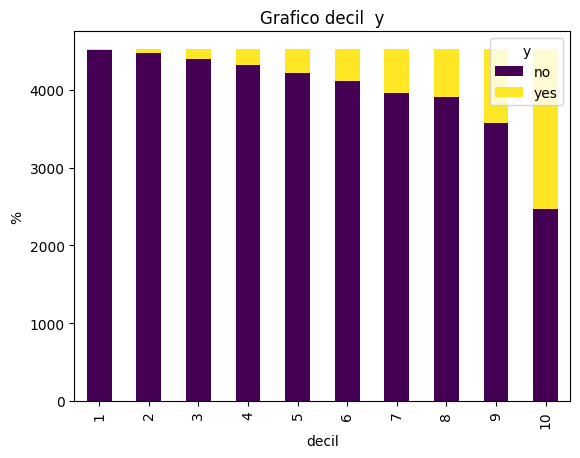

In [50]:
graficoBarApiladas(rs, 'decil', 'y')

### Information Value (IV) 

Information Value (IV) es una medida utilizada en el análisis predictivo para evaluar la importancia de una variable independiente en la predicción de una variable dependiente binaria (por ejemplo, riesgo crediticio). Aquí tienes una función en Python que calcula el Information Value para una variable categórica:

In [52]:
def calculate_iv(data, feature, target):
    """
    Calcula el Information Value (IV) para una variable categórica.
    
    Parameters:
    - data: DataFrame que contiene los datos.
    - feature: El nombre de la columna de la variable categórica.
    - target: El nombre de la columna de la variable dependiente binaria.
    
    Returns:
    - iv: El valor de IV para la variable especificada.
    """
    # Crear una tabla de frecuencia para la variable y el target
    freq_table = pd.crosstab(data[feature], data[target])
    
    # Calcular las proporciones de buenos y malos
    freq_table['good'] = freq_table[0] / freq_table[0].sum()
    freq_table['bad'] = freq_table[1] / freq_table[1].sum()
    
    # Calcular el WoE (Weight of Evidence) y el IV para cada categoría
    freq_table['WoE'] = np.log(freq_table['good'] / freq_table['bad'])
    freq_table['IV']  = (freq_table['good'] - freq_table['bad']) * freq_table['WoE']
    
    # Sumar el IV total
    iv = freq_table['IV'].sum()
    
    return iv

def histograma(data,variable,bins=30):
    #histograma
    sns.histplot(data[variable], bins=bins, kde=True)

    # Añadir etiquetas y título
    plt.xlabel('Valor de '+variable)
    plt.ylabel('Frecuencia')
    plt.title('Histograma de '+variable)

    # Mostrar el gráfico
    plt.show()
    


Calculamos el IV para una variable categórica

In [56]:
iv_value = calculate_iv(marketing, 'loan', 'y')
print(f"Information Value: {iv_value}")

Information Value: 0.054858526982233244


Calculamos el IV para una variable continua

In [55]:
#creamos 10 bines y la convertimos a  categorica
marketing['balance_bin'] = pd.qcut(marketing['balance'], q=10, labels=False)
iv_value      = calculate_iv(marketing, 'balance_bin', 'y')
print(f"Information Value: {iv_value}")

Information Value: 0.1019386058018926
